In [64]:
from pathlib import Path
import numpy as np
import json
import pickle
import matplotlib.pyplot as plt
from scipy.stats import lognorm, norm

from standes.analysis.recorders import get_recorder, get_recorders
from standes.fragility_curves import fragility_from_msa
from standes.fitting import lognorm_mle_fit
from phd_project.config import config

cfg = config.load_config()

In [ ]:
N_STOREYS = [3]

ANALYSIS_ROOT = cfg["analysis_data"]["wp1_casestudy_sites"]
RESULTS_ROOT = cfg["results"]["site_fragility_curves"]
FRAG_ROOT = cfg["proc_data"]["wp1_sites_fragility_curves"]
STRIPE_IML_PATH = Path(r"C:\Users\clemettn\Documents\phd\data_processed\05_gcim_distributions\imls_for_selection_AvgSA_03.json")
G = 9810    # mm/s²

PC_UPPER_THRESHOLD = 0.7 # the minimum upper collapse probabilty to consider a fragility curve as well defined.
PC_LOWER_THRESHOLD = 0.2 # the maximum lower collapse probabilty to consider a fragility curve as well defined.

def structure_tag(site_idx: int, n: int) -> str:
    return f"{n}s_cbf_dc2_site{site_idx}"

## Load Fragility Curves

In [66]:
# Load the stripe IMLs for the MSA
with open(STRIPE_IML_PATH, "r") as file:
    stripe_imls = json.load(file)

In [ ]:
sites = list(range(0, 60))

not_well_defined = {"lt_upper_threshold": [],
                    "gt_lower_threshold": []}

fragility_curves = {}

for site in sites:#[34:35]:
    site_fcs = {}
    for ns in N_STOREYS:
        structure_fcs = {}
        # building tag
        tag = structure_tag(site, ns)
        save_folder = RESULTS_ROOT / f"site_{site}" / f"{ns}s"
        save_folder.mkdir(parents=True, exist_ok=True)

        # load a fragility curve
        fc_path = ANALYSIS_ROOT / f"site_{site}" / f"{ns}s/mdof/msa_AvgSA_03/collapse_fragility.json"
        if not fc_path.parent.exists():
            print(f"No MSA Data for site {site} and {ns}s. Skipping...")
            continue

        try:    
            with open(fc_path, "r") as file:
                fc = json.load(file)
                fc = {k: np.array(v) if isinstance(v, list) else v for k, v in fc.items()}
        except FileNotFoundError:
            print(f"No Fragility Curve for site {site} and {ns}s. Skipping...")
            continue

        if max(fc["efc"][1, :]) <= PC_UPPER_THRESHOLD:
            not_well_defined["lt_upper_threshold"].append((site, ns))

        if min(fc["efc"][1, :]) >= PC_LOWER_THRESHOLD:
            not_well_defined["gt_lower_threshold"].append((site, ns))

        im_max = lognorm.ppf(0.99, s=fc["dispersion"], scale=fc["median"])
        imls = np.linspace(0, im_max*1.15, 50) # in g
        
        msa_fc_fit = lognorm.cdf(imls, s=fc["dispersion"], scale=fc["median"])
        structure_fcs["msa"] = fc

        # get the stripe imls
        building_stripe_imls = stripe_imls[str(site)][tag]


        # load FEMA-P695 IDA fragility - load from processed data
        fc_path =  FRAG_ROOT / f"site_{site}" / f"{tag}_ida_femap695_collapsefragility_AvgSA_03.json"
        try:    
            with open(fc_path, "r") as file:
                fc_p695 = json.load(file)
                fc_p695 = {k: np.array(v) if isinstance(v, list) else v for k, v in fc_p695.items()}
        except FileNotFoundError:
            print(f"No Fragility Curve for site {site} and {ns}s. Skipping...")
            continue
        idapfema695_fc_fit = lognorm.cdf(imls, s=fc_p695["dispersion"], scale=fc_p695["median"])
        structure_fcs["ida-femap695"] = fc_p695

        # TODO:: load fragility curve of IDA-EU
        site_fcs[tag] = structure_fcs

        # plot fragility curve
        fig, ax = plt.subplots(figsize=(6, 4))
        plt.close(fig)

        for siml in building_stripe_imls:
            if siml is not None:
                ax.axvline(siml, ls="--", color="k", alpha=0.5)

        ax.plot(imls, msa_fc_fit, color="b", label="MSA")
        ax.plot(fc["efc"][0, :], fc["efc"][1, :], ls="none", marker="o", mfc="b", mec="k", alpha=0.75, label="MSA ecdf")

        ax.set_ylim(0, 1)
        ax.grid(ls="-.", color="0.8")
        ax.set_xlabel("AvgSA[0,3], [g]")
        ax.set_ylabel("Probability of Collapse, P[C]")
        ax.set_title(f"Fragility Curves - Site {site}, {ns}s")
        leg = ax.legend()
        frame = leg.get_frame()
        frame.set_edgecolor("k")
        fig.savefig(RESULTS_ROOT / f"fragility_curves_site_{site}_{ns}s.jpg", dpi=300, bbox_inches="tight")

    fragility_curves[site] = site_fcs

print(f"\nSites with not well defined fragility curves (P[C] < {PC_UPPER_THRESHOLD}):\n {not_well_defined['lt_upper_threshold']}\n")
print(f"Sites with not well defined fragility curves (P[C] > {PC_LOWER_THRESHOLD}):\n {not_well_defined['gt_lower_threshold']}")

No MSA Data for site 24 and 3s. Skipping...
No MSA Data for site 31 and 3s. Skipping...
No MSA Data for site 38 and 3s. Skipping...
No Fragility Curve for site 55 and 3s. Skipping...

Sites with not well defined fragility curves (P[C] < 0.7):
 [(1, 3), (2, 3), (3, 3), (4, 3), (10, 3), (13, 3), (15, 3), (16, 3), (27, 3), (30, 3), (32, 3), (33, 3), (34, 3), (35, 3), (36, 3), (42, 3), (43, 3), (48, 3), (50, 3), (53, 3)]

Sites with not well defined fragility curves (P[C] > 0.2):
 [(4, 3), (12, 3), (17, 3), (22, 3), (23, 3), (27, 3), (28, 3), (37, 3), (44, 3), (49, 3), (57, 3), (58, 3)]


In [68]:

# site = 0
# record = 0
# ns = 3      # number of stories
# stripe = "00pt500"

# SITE_FOLDER = Path(f"D:/07_wp1_casestudy_sites/site_{site}")
# STOREY_FOLDER = SITE_FOLDER / f"{ns}s"                   
# MSA_FOLDER = STOREY_FOLDER / f"mdof/msa_AvgSA_03"
# STRIPE_FOLDER = MSA_FOLDER / f"stripe_{stripe}"

# PROC_FRAG_FOLDER = Path(r"C:\Users\clemettn\Documents\phd\data_processed\09_structure_fragility_curves\wp1_casestudy_sites")

# record_log_fp =  STRIPE_FOLDER / f"record_{record}_log.json"
# with open(record_log_fp, "r") as file:
#     log = json.load(file)

# collapse_recorders_fp = STRIPE_FOLDER / f"record_{record}_collapse_recorders.pickle"
# with open(collapse_recorders_fp, "rb") as file:
#     colrecs = pickle.load(file) 

# recorders_fp = STRIPE_FOLDER / f"record_{record}_recorders.pickle"
# with open(recorders_fp, "rb") as file:
#     recs = pickle.load(file) 

# time_arr_fp = STRIPE_FOLDER / f"record_{record}_timearray.pickle"
# with open(time_arr_fp, "rb") as file:
#     time_arr = pickle.load(file) 


# cfc_fp = MSA_FOLDER / "collapse_fragility.json"
# with open(cfc_fp, "r") as file:
#     msa_fc = json.load(file) 

# # Log the AvgSA[0,3] fragility curve from processed results
# cfc_fp = PROC_FRAG_FOLDER / f"{ns}s_cbf_dc2_site{site}_collapsefragility_AvgSA_03.json"
# with open(cfc_fp, "r") as file:
#     idap695_fc = json.load(file) 

In [69]:
# ims = np.linspace(0, 1, 50) # in g
# g = 9810    # mm/s²
# msa_fc_fit = lognorm.cdf(ims, s=msa_fc["dispersion"], scale=msa_fc["median"])
# idap695_fc_fit = lognorm.cdf(ims * g, s=idap695_fc["dispersion"], scale=idap695_fc["median"])

In [70]:
# fig, ax = plt.subplots()
# ax.plot(msa_fc["efc"][0], msa_fc["efc"][1], ls="none", marker="o", mfc="b", mec="k")
# ax.plot(np.array(idap695_fc["efc"][0]) / g, idap695_fc["efc"][1], ls="none", marker="o", mfc="r", mec="k")
# ax.plot(ims, idap695_fc_fit, color="r", label="IDA-P695")
# ax.plot(ims, msa_fc_fit, color="b", label="MSA")
# ax.set_xlabel("AvgSA[0, 3] [g]")
# ax.set_ylabel("P[collapse]")
# ax.grid(ls="-.", color="0.8")
# ax.legend()

## Uncertainty Estimation

There is uncertainty associated with the analysis method and the subsequent fitting of the fragility curves. To be able to decide of the differences between the IDA- and MSA-derived fragility curves are significant we need to compare the distributions of the median and dispersion values. Using parametric resampling we can quantify the distribution of these quantities. The parameteric resampling method used in described by Iervolino (2022): "Estimation uncertainty for some common seismic fragility curve fitting methods."

In [71]:
for site in fragility_curves.keys():
    for structure, fc in fragility_curves[site].items():
        # evaluate the fitted fragility curve at the stripe IMLs, pi
        ...
        # for each trial, k
            # for each stripe IML, i
                # sample a new P[C] using the binomial distribution with p = pi 
            # fit a new fragility curve to the sampled P[C] values
        
        # Estimate the distribution of the fragility parameters (median and dispersion)
        # Calculate the 5-95% and 10-90% confidence intervals for the fragility curve parameters
  

MLE Estimates (normal): 0.4183048933136721 0.03322619186058114
Normal Assumption: 0.4183048933136721 0.04549833943396147
90% CI Width 0.10930444438332476
95% CI Width 0.13024427878031375


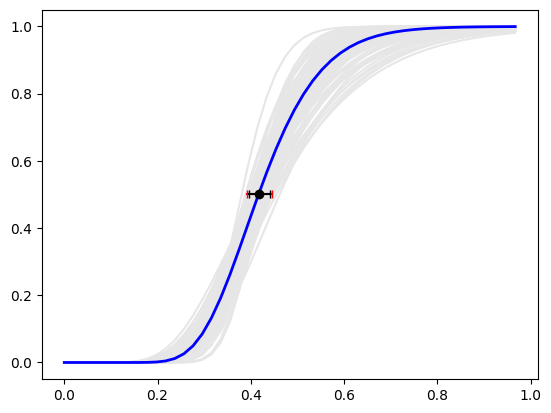

In [ ]:
n_tests = 30        # number of records per stripe
k_trials = 100        # number of fragility curves to create

fc = fragility_curves[0]["3s_cbf_dc2_site0"]["msa"]

collapses = []
for im in fc["efc"][0, :]:
    p = lognorm.cdf(im, s=fc["dispersion"], scale=fc["median"])

    im_collapse_samples = np.random.binomial(n_tests, p, size=k_trials)
    collapses.append(im_collapse_samples)

ims = fc["efc"][0, :]
collapses = np.column_stack(collapses)

sim_fcs = []
for row in collapses:
    sim_fcs.append(fragility_from_msa(ims, row, n_tests))


fig, ax = plt.subplots()

im_max = lognorm.ppf(0.99, s=fc["dispersion"], scale=fc["median"])
imls = np.linspace(0, im_max*1.3, 50) # in g

for sfc in sim_fcs:
    ax.plot(imls, lognorm.cdf(imls, s=sfc.dispersion, scale=sfc.median),
            color="0.9")


base_fc = lognorm.cdf(imls, s=fc["dispersion"], scale=fc["median"])
ax.plot(imls, base_fc, color="blue", lw=2)

mean_lnAvgSA = [np.log(sfc.median) for sfc in sim_fcs]
sigma_lnAvgSA = [sfc.dispersion for sfc in sim_fcs]

# distribution of the mean of lnAvgSA
mu_mle, std_mle = norm.fit(mean_lnAvgSA)
print("MLE Estimates (normal):", np.exp(mu_mle), std_mle)
print("Normal Assumption:", np.exp(np.mean(mean_lnAvgSA)), fc["dispersion"] / np.sqrt(n_tests))
ci_90 = norm.interval(0.90, loc=mu_mle, scale=std_mle)
ci_95 = norm.interval(0.95, loc=mu_mle, scale=std_mle)
print("90% CI Width", ci_90[1] - ci_90[0])
print("95% CI Width", ci_95[1] - ci_95[0])
ax.plot(np.exp(mu_mle), 0.5, marker="o", mfc="k", mec="k")
ax.plot(np.exp(ci_95), [0.5, 0.5], color="r", marker="|", mec="r")
ax.plot(np.exp(ci_90), [0.5, 0.5], color="k", ls="-", marker="|", mec="k")

# distribution of the sigma of lnAvgSA
# this is a

FragilityCurve(fragility_type='collapse', limit_state='collapse', limit_value=None, median=0.41072013782167255, dispersion=0.2036997091316506, efc=[[np.float64(0.31), np.float64(0.36), np.float64(0.4), np.float64(0.5)], [np.float64(0.06666666666666667), np.float64(0.23333333333333334), np.float64(0.5333333333333333), np.float64(0.8)]], intensity_measure=None)

## Save Results

In [ ]:
sites = list(range(0, 60))
for site in sites:
    # TODO:: move fema p695 ida fragility curve

    # copy msa fragility curves to results
    
    
    ...